# 🧩 04 — Pré-processamento & Perfilamento Fenotípico (Base .db)

**Curso de HCA — Módulo Pycytominer**  
**Notebook anotado:** `01_Samples_retrieval_database_clean.ipynb` → `*_annotated.ipynb`  
**Data:** 2025-10-14

> Este notebook foi anotado para conectar cada etapa prática com a teoria do capítulo  
> **“04_preprocessamento_pycytominer.md”**. Os **comentários** não alteram seu código original.

**Fluxo geral**
1. Abrir o **SQLite (.db)** do CellProfiler e inspecionar tabelas.
2. Ler por **compartimento** (Cells, Cytoplasm, Nuclei) e **metadados**.
3. **Prefixar** *features* por compartimento (evita colisões de nomes).
4. **Unir** compartimentos (mais **colunas**) e **concatenar** placas/dias (mais **linhas**).
5. Exportar **SingleCells** consolidado para uso no **pycytominer**.

> 🔗 **Ligação com a teoria:** ver seção *“Relembrando: como o CellProfiler organiza os dados”* e *“Etapa 1–4”* no documento do módulo.  
> - Linhas = células / objetos.  
> - Colunas = *features* (área, textura, intensidade etc.) + `Metadata_*`.  
> - Prefixos: `Cells_`, `Cytoplasm_`, `Nuclei_`.  
> - `SingleCells.csv` = base para normalização, seleção de *features* e perfis.

# 01 — Samples Retrieval (SQLite → Single-Cell Profiles)

**Objetivo:** Extrair *single-cell features* diretamente de bancos SQLite exportados do CellProfiler, de forma **agnóstica de sistema operacional** e **sem janelas/GUI** (sem `easygui`).  
**Este notebook não faz anotação com platemap, nem leitura de CSV de platemap.** A anotação deve ser feita em um notebook separado (ex.: `02_Agg_Annotate_Normalize_FeatureSelect.ipynb`).

### O que este notebook faz
- Descobre placas automaticamente num diretório raiz (`DB_ROOT`), assumindo a convenção `DB_ROOT/<PLATE>/<PLATE>.db`.
- Lê as tabelas `Per_Image` e `Per_<Compartimento>` (ex.: `Per_Cells`, `Per_Cytoplasm`, `Per_Nuclei`).
- **Garante metadados padronizados**: `Metadata_Plate`, `Metadata_Well`, `Metadata_Site` e normalização de poços (`A1` → `A01`).
- Concatena *features* de compartimentos e remove colunas duplicadas.
- Exporta um CSV com *single-cell profiles* e outro com a contagem de objetos por poço (útil para *aggregate* mais tarde).

### 📦 Conectando e lendo o banco `.db` do CellProfiler
**Objetivo:** Abrir o SQLite e carregar tabelas relevantes.  
**Por que:** Ler diretamente do `.db` permite **IO eficiente** e **seleção de colunas**.

**Boas práticas:**
- Valide os nomes de tabelas/colunas (`PRAGMA table_info`) quando houver dúvida.
- Garanta que `Metadata_*` (ex.: `Metadata_Well`, `Metadata_Site`) sejam carregados.

In [33]:
from pathlib import Path
from typing import List
import sqlite3
import pandas as pd
import re
from typing import Sequence, Optional

pd.set_option("display.max_columns", 200)

## 🧰 1) Configuração inicial

Antes de iniciarmos a construção do dataset, precisamos **definir algumas variáveis fundamentais**, que serão usadas em todo o notebook.  
Essas variáveis indicam **onde estão os dados de entrada**, **quais objetos foram medidos** e **onde salvar os resultados**.  

| Variável | Função | Exemplo | Observações |
|-----------|---------|----------|-------------|
| `DB_ROOT` | Caminho da pasta onde estão armazenados os bancos de dados (`.db`) gerados pelo CellProfiler. | `"./workspace/database"` | Cada `.db` normalmente representa uma placa ou replicata biológica. |
| `COMPARTMENTS` | Lista dos compartimentos (*objects*) que você utilizou no pipeline do CellProfiler. | `["Cells", "Cytoplasm", "Nuclei"]` | Mantenha o padrão sugerido, a menos que tenha modificado o pipeline (ex.: adicionou “Vesicles”). |
| `OUTPUT_DIR` | Diretório onde será salvo o arquivo consolidado (`SingleCells.csv`). | `"./workspace/analysis"` | É criado automaticamente se ainda não existir. |

💡 **Dica:** mantenha esses caminhos consistentes com a estrutura do seu projeto (`images/`, `workspace/`, `analysis/`).  
Isso garante compatibilidade com outros scripts e notebooks do curso.

---

### 🧠 Contexto teórico

> 🔗 Essa etapa corresponde ao início do “Etapa 4 — Escolher a rotina de pré-processamento” no documento teórico.  
>  
> Aqui estamos apenas **preparando o ambiente**, definindo os pontos de entrada e saída.  
> A lógica geral é:
> - `DB_ROOT` → onde estão as informações *brutas* (por placa ou experimento).  
> - `COMPARTMENTS` → define **quais tabelas** serão buscadas dentro do `.db`.  
> - `OUTPUT_DIR` → onde será gerado o arquivo unificado de **SingleCells**, que servirá de base para o *pycytominer*.  

In [46]:
# Raiz onde estão as placas
# DB_ROOT = Path("/PATH/TO/PROJECT/workspace/database")  # <- ajuste aqui
DB_ROOT = Path("/Users/marcelobispojesus/Documents/dev/keila/LCP_Nanoplastics_70nm_Huh7/workspace/backend/npps/")  # <- ajuste aqui

# Compartimentos a extrair (tabelas Per_*) — ajuste se necessário
COMPARTMENTS: Sequence[str] = ("Cells", "Cytoplasm", "Nuclei")

# Pasta de saída
OUTPUT_DIR = Path("./outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 🧩 2) Utilitários

Abaixo definimos duas funções auxiliares usadas em várias etapas do processamento:

- **`_norm_well`** — normaliza identificadores de poços (*wells*) para o formato canônico de placa **96-well** (`A01–H12`).  
  Essa padronização garante consistência no campo `Metadata_Well`, o que é essencial para operações de *merge*, *groupby* e comparações estáveis entre placas e experimentos.

- **`ensure_core_metadata`** — harmoniza os nomes e formatos dos **metadados centrais** do CellProfiler dentro do *DataFrame*.  
  Ela assegura que colunas como `Metadata_Plate`, `Metadata_Well` e `Metadata_Site` estejam corretamente nomeadas e formatadas antes de unirmos compartimentos, concatenarmos placas e gerarmos perfis fenotípicos com o *pycytominer*.

In [47]:
def _norm_well(x: str) -> str:
    s = str(x).strip().upper()
    import re as _re
    m = _re.match(r"^([A-H])0?([1-9]|1[0-2])$", s)
    return f"{m.group(1)}{int(m.group(2)):02d}" if m else s

def ensure_core_metadata(df: pd.DataFrame, plate_value: Optional[str] = None) -> pd.DataFrame:
    rename_map = {
        "Image_Metadata_Plate": "Metadata_Plate",
        "Image_Metadata_Well":  "Metadata_Well",
        "Image_Metadata_Site":  "Metadata_Site",
    }
    cols_to_rename = {k: v for k, v in rename_map.items() if k in df.columns}
    if cols_to_rename:
        df = df.rename(columns=cols_to_rename)
    if "Metadata_Plate" not in df.columns and plate_value is not None:
        df["Metadata_Plate"] = plate_value
    if "Metadata_Well" in df.columns:
        df["Metadata_Well"] = df["Metadata_Well"].map(_norm_well)
    if "Metadata_Site" not in df.columns and "Site" in df.columns:
        df = df.rename(columns={"Site": "Metadata_Site"})
    return df

## 3) Leitura por placa (SQLite)

### 📦 Conectando e lendo o banco `.db` do CellProfiler
**Objetivo:** Abrir o SQLite e carregar tabelas relevantes.  
**Por que:** Ler diretamente do `.db` permite **IO eficiente** e **seleção de colunas**.

**Boas práticas:**
- Valide os nomes de tabelas/colunas (`PRAGMA table_info`) quando houver dúvida.
- Garanta que `Metadata_*` (ex.: `Metadata_Well`, `Metadata_Site`) sejam carregados.

### 🔗 Unindo compartimentos (merge por chaves)
**Objetivo:** Trazer `Cells`, `Cytoplasm` e `Nuclei` para **um único DataFrame**.  
**Chaves típicas:** `Metadata_ImageNumber` + `Metadata_ObjectNumber` (ajuste conforme seu pipeline).

> **Sanity check:** Após o *merge*, o número de linhas deve ser compatível (inner join pode descartar objetos sem correspondência).

### ➕ Concatenando placas/dias (replicatas biológicas)
**Objetivo:** Unificar **todas as placas/dias** em um só conjunto (mais **linhas**).  
**Boas práticas:** Adicione um identificador de batch (ex.: `Metadata_Batch`/`Metadata_PlateDir`) antes de concatenar.

In [62]:
def read_plate_from_sqlite(plate_entry: Path, compartments: Sequence[str]) -> pd.DataFrame:
    """
    Lê uma placa a partir de:
      - um DIRETÓRIO contendo <dir>/<dir>.db   (convenção 'nested'), ou
      - um ARQUIVO .db diretamente (convenção 'flat').

    Mantém a lógica original de leitura das tabelas Per_<compartment>.
    """
    plate_entry = Path(plate_entry)

    # 1) Resolver o caminho do .db e o 'plate_id' (para Metadata_Plate)
    if plate_entry.is_file() and plate_entry.suffix == ".db":
        db_path = plate_entry
        plate_id = plate_entry.stem
    elif plate_entry.is_dir():
        cand = plate_entry / f"{plate_entry.name}.db"
        if cand.exists():
            db_path = cand
            plate_id = plate_entry.name
        else:
            # fallback: se houver exatamente um .db na pasta, use-o
            dbs = list(plate_entry.glob("*.db"))
            if len(dbs) == 1:
                db_path = dbs[0]
                plate_id = db_path.stem
            else:
                raise FileNotFoundError(f"DB não encontrado: {plate_entry}")
    else:
        raise FileNotFoundError(f"Entrada inválida: {plate_entry}")

    if not db_path.exists():
        raise FileNotFoundError(f"DB não encontrado: {db_path}")

    # 2) Leitura
    with sqlite3.connect(str(db_path)) as conn:
        df_img = pd.read_sql_query("SELECT * FROM Per_Image", conn)
        df_img = df_img.rename(columns={
            "Image_Metadata_Site":  "Metadata_Site",
            "Image_Metadata_Plate": "Metadata_Plate",
            "Image_Metadata_Well":  "Metadata_Well",
        })
        meta_cols = [c for c in ["ImageNumber", "Metadata_Plate", "Metadata_Well", "Metadata_Site"]
                     if c in df_img.columns]
        df_meta = df_img[meta_cols].copy()

        dfs = []
        for cmpt in compartments:
            tbl = f"Per_{cmpt}"
            try:
                df_c = pd.read_sql_query(f"SELECT * FROM {tbl}", conn)
                dfs.append(df_c)
            except Exception as e:
                print(f"⚠️ Falha ao ler {tbl} em {db_path.name}: {e}")

    if not dfs:
        raise RuntimeError(f"Nenhuma tabela de compartimento encontrada em {db_path}")

    # 3) Combina as tabelas de compartimento (mesma estratégia do código original)
    df_feat = pd.concat(dfs, axis=1)
    df_feat = df_feat.loc[:, ~df_feat.columns.duplicated()].copy()

    if "ImageNumber" in df_feat.columns and "ImageNumber" in df_meta.columns:
        df = df_meta.merge(df_feat, on="ImageNumber", how="right")
    else:
        df = pd.concat([df_meta, df_feat], axis=1)

    # 4) Harmoniza metadados (usa 'plate_id' resolvido acima)
    df = ensure_core_metadata(df, plate_value=plate_id)
    return df

## 🧭 4) Descoberta automática de placas

Antes de unificar os dados, precisamos identificar onde estão os bancos de dados (`.db`) gerados pelo CellProfiler.  
Dependendo de como o experimento foi organizado, os arquivos podem estar dispostos de duas formas diferentes — e o código abaixo consegue lidar automaticamente com ambas.

---

### 📂 Estruturas possíveis

O CellProfiler salva os resultados de cada placa em um banco SQLite (`.db`).  
Existem duas formas comuns de organizar esses arquivos:

| Estrutura | Exemplo de caminho | Descrição |
|------------|--------------------|------------|
| **Flat** | `.../workspace/backend/npps/250808_102354_Plate_1.db` | Todos os arquivos `.db` estão diretamente dentro da mesma pasta. |
| **Nested** | `.../workspace/backend/npps/250808_102354_Plate_1/250808_102354_Plate_1.db` | Cada placa possui uma subpasta com o mesmo nome do arquivo. Essa era a convenção usada em versões anteriores do curso. |

O código abaixo detecta automaticamente qual estrutura está sendo usada e lista todos os bancos de dados disponíveis no diretório definido em `DB_ROOT`.

---

### ⚙️ Funções de descoberta

As funções abaixo buscam e listam os bancos de dados `.db` dentro da pasta configurada, independentemente da estrutura (flat ou nested).



In [63]:
def discover_plate_dbs_flex(db_root: Path) -> List[Path]:
    """
    Detecta bancos .db em dois esquemas:
    - FLAT:   db_root/*.db
    - NESTED: db_root/<placa>/<placa>.db
    Retorna uma lista de paths para arquivos .db.
    """
    out: List[Path] = []

    if not db_root.exists():
        print(f"⚠️ DB_ROOT não existe: {db_root}")
        return out

    # 1) Coleta FLAT: arquivos .db diretamente na raiz
    out.extend(sorted(db_root.glob("*.db")))

    # 2) Coleta NESTED: subpastas com um .db de mesmo nome
    for p in db_root.iterdir():
        if p.is_dir():
            cand = p / f"{p.name}.db"
            if cand.exists():
                out.append(cand)

    # Remove duplicatas e ordena
    out = sorted(set(out))
    return out

def plate_name_from_db(db_path: Path) -> str:
    """Ex.: '/.../250808_102354_Plate_1.db' -> '250808_102354_Plate_1'"""
    return db_path.stem

🔍 Execução e verificação

In [66]:
DB_FILES = discover_plate_dbs_flex(DB_ROOT)
print(f"Placas detectadas ({len(DB_FILES)}):",
      [plate_name_from_db(p) for p in DB_FILES][:10],
      "..." if len(DB_FILES) > 10 else "")

dfs = []
for db_path in DB_FILES:
    try:
        # 👉 Agora db_path já é o ARQUIVO .db. Não concatenar mais nada.
        df_plate = read_plate_from_sqlite(db_path, COMPARTMENTS)
        dfs.append(df_plate)
        print(f"✓ Lido: {db_path.name} — shape {df_plate.shape}")
    except Exception as e:
        print(f"✗ Erro ao ler {db_path.name}: {e}")

if not dfs:
    raise SystemExit("Nenhuma placa válida encontrada.")

df_all = pd.concat(dfs, axis=0, ignore_index=True)
print(f"✅ Total combinado: {df_all.shape[0]:,} células, {df_all.shape[1]} colunas.")

Placas detectadas (3): ['250808_102354_Plate_1', '250813_094546_Plate_1', '250815_094252_Plate_2'] 
✓ Lido: 250808_102354_Plate_1.db — shape (11843, 1811)
✓ Lido: 250813_094546_Plate_1.db — shape (14280, 1811)
✓ Lido: 250815_094252_Plate_2.db — shape (12229, 1811)
✅ Total combinado: 38,352 células, 1811 colunas.


### 🧠 Contexto teórico

🔗 Esta etapa corresponde à “descoberta automática de placas” mencionada no início da seção de pré-processamento.
É aqui que garantimos que todas as replicatas biológicas (dias, placas ou lotes) serão incluídas na análise.
Cada arquivo .db representa uma placa e será lido separadamente nas etapas seguintes, quando uniremos os dados em um único DataFrame consolidado (SingleCells).

⸻

### 💡 Boas práticas

 - Use nomes de arquivo claros que identifiquem data, lote e placa (`YYYYMMDD_HHMM_Plate_1.db`, por ex. 250815_094252_Plate_2).
 - Verifique se todos os .db têm o mesmo formato interno (mesmas tabelas e colunas).
 - Se preferir a estrutura nested, mantenha o padrão `<placa>/<placa>.db>` — isso facilita automatizar pipelines em lote.

## ⚙️ 5) Execução e consolidação das placas

Após identificar os bancos de dados (`.db`) das placas, agora vamos ler, combinar e exportar todas as informações em um único arquivo consolidado — o **SingleCells.csv**.

---

### ➕ Unindo placas / replicatas biológicas

**Objetivo:** Ler todas as placas listadas em `DB_FILES` e unificá-las em um só *DataFrame* — cada placa adiciona **novas linhas** ao conjunto final.  

Cada arquivo `.db` representa uma **replicata biológica** (por exemplo, um dia experimental).  
O código abaixo lê cada banco, extrai as *features* dos compartimentos definidos em `COMPARTMENTS` e adiciona tudo a uma lista.

💡 **Boas práticas**
- Adicione metadados que identifiquem a origem da placa (ex.: `Metadata_Batch` ou `Metadata_Plate`).  
- Mantenha o mesmo número e tipo de colunas entre placas para garantir compatibilidade durante a concatenação.  
- Caso algum banco apresente erro, ele será ignorado e o código continuará processando os demais.


In [67]:
dfs = []

for db_path in DB_FILES:
    try:
        df_plate = read_plate_from_sqlite(db_path, COMPARTMENTS)
        dfs.append(df_plate)
        print(f"✓ Lido: {db_path.name} — shape {df_plate.shape}")
    except Exception as e:
        print(f"✗ Erro ao ler {db_path.name}: {e}")

if not dfs:
    raise SystemExit("Nenhuma placa válida encontrada.")

# Une todas as placas (concatena as linhas)
df_all = pd.concat(dfs, axis=0, ignore_index=True)
print(f"✅ Total combinado: {df_all.shape[0]:,} células, {df_all.shape[1]} colunas.")

✓ Lido: 250808_102354_Plate_1.db — shape (11843, 1811)
✓ Lido: 250813_094546_Plate_1.db — shape (14280, 1811)
✓ Lido: 250815_094252_Plate_2.db — shape (12229, 1811)
✅ Total combinado: 38,352 células, 1811 colunas.



### 💾 Exportando o arquivo `SingleCells`

**Objetivo:** Salvar o dataset consolidado para uso nas próximas etapas do **pycytominer** e de análises fenotípicas.

O nome do arquivo pode ser ajustado livremente, mas recomenda-se um formato descritivo, como:

```
<Experimento>_SingleCells.csv
exemplo: NPPS_24h_SingleCells.csv
```

O código abaixo salva o resultado na pasta `outputs/` (será criada automaticamente, se não existir).

In [68]:
from pathlib import Path

single_cell_csv = Path("./outputs/single_cell_profiles.csv")
single_cell_csv.parent.mkdir(parents=True, exist_ok=True)
df_all.to_csv(single_cell_csv, index=False)
print("💾 Arquivo salvo em:", single_cell_csv)

💾 Arquivo salvo em: outputs/single_cell_profiles.csv


### 🧠 Contexto teórico

> 🔗 Esta etapa corresponde à “Etapa 2 — Unir experimentos independentes (placas biológicas)” do módulo teórico.  
> Aqui, combinamos os resultados de todas as placas em um único conjunto **SingleCells**, que representa todas as células analisadas no experimento.  
> Esse arquivo será a base para:
> - **Normalização e seleção de features** (com o *pycytominer*),  
> - **Geração de perfis fenotípicos**,  
> - e análises de similaridade, clustering e explicabilidade.

---

### 🧯 Troubleshooting

| Problema | Causa provável | Solução sugerida |
|---|---|---|
| ⚠️ Nenhum arquivo detectado | Caminho de `DB_ROOT` incorreto | Confirme o diretório e se os `.db` estão visíveis via `ls` |
| ❌ Erro ao ler uma placa | `.db` corrompido ou colunas faltantes | Verifique com `sqlite3 <arquivo.db> .tables` |
| ⚠️ Colunas ausentes após concatenação | Estruturas diferentes entre placas | Padronize pipelines e use `ensure_core_metadata` antes de exportar |
| 🐢 Execução lenta | `.db` muito grandes | Limite colunas lidas no `read_plate_from_sqlite` (ex.: `columns=['Metadata_Well','Cells_AreaShape_Area', ...]`) |

## 6) (Opcional) Contagem de objetos por poço

### 🧱 Prefixando *features* por compartimento
**Objetivo:** Evitar colisões de nomes ao unificar as tabelas.  
**Exemplos:** `AreaShape_Area` → `Cells_AreaShape_Area`, `Cytoplasm_AreaShape_Area`, `Nuclei_AreaShape_Area`.

> **Atenção:** **Não** prefixe metadados (`Metadata_*`). Eles atuam como chaves e rótulos.

### 💾 Exportando o `SingleCells` consolidado
**Objetivo:** Salvar a base única para as próximas etapas do **pycytominer**.  
**Sugestão de nome:** `<EXPERIMENTO>_SingleCells.csv` (ex.: `NPPS_24h_SingleCells.csv`).

> Mantenha o arquivo acompanhado de um `README` curto, descrevendo batch/placas e contagens.

In [69]:
count_candidates = ["Nuclei_Number_Object_Number", "Cells_Number_Object_Number", "Number_Object_Number", "ObjectNumber"]
count_col = next((c for c in count_candidates if c in df_all.columns), None)
if count_col:
    object_count = (
        df_all.groupby(["Metadata_Plate", "Metadata_Well"])[count_col]
        .count()
        .reset_index()
        .rename(columns={count_col: "Metadata_cell_count"})
    )
    obj_csv = Path("./outputs/object_count_per_well.csv")
    object_count.to_csv(obj_csv, index=False)
    print("Salvo:", obj_csv)
else:
    print("⚠️ Não encontrei coluna de contagem de objetos. Pulei esta exportação.")

Salvo: outputs/object_count_per_well.csv


In [72]:
object_count

,Metadata_Plate,Metadata_Well,Metadata_cell_count
0,250808_102354_Plate_1_,B03,220
1,250808_102354_Plate_1_,B06,205
2,250808_102354_Plate_1_,B07,227
3,250808_102354_Plate_1_,B08,198
4,250808_102354_Plate_1_,B09,157
...,...,...,...
165,250815_094252_Plate_1_,G07,145
166,250815_094252_Plate_1_,G08,252
167,250815_094252_Plate_1_,G09,221
168,250815_094252_Plate_1_,G10,239


In [101]:
def plot_plate_heatmap(
    df: pd.DataFrame,
    plate_name: str,
    vmin: Optional[float]=None,
    vmax: Optional[float]=None,
    annotate: bool=True,
    fmt: str=".0f",
    fontsize: int=8,
    show_grid: bool=True,          # <- NOVO: liga/desliga o grid
    grid_linewidth: float=0.6,     # <- espessura do grid
    grid_alpha: float=0.6          # <- transparência do grid
):
    """
    Plota um heatmap de uma única placa e, opcionalmente:
      - anota os valores por poço (annotate)
      - desenha grid entre as células (show_grid)
    """
    mat = _pivot_plate(df)  # 8x12 (linhas A..H, colunas 01..12)

    fig, ax = plt.subplots(figsize=(8, 5.5))
    im = ax.imshow(mat.values, aspect="auto", vmin=vmin, vmax=vmax)  # colormap padrão

    # Ticks / labels
    ax.set_xticks(np.arange(len(COLS)))
    ax.set_yticks(np.arange(len(ROWS)))
    ax.set_xticklabels(COLS)
    ax.set_yticklabels(ROWS)
    ax.set_xlabel("Coluna (01–12)")
    ax.set_ylabel("Linha (A–H)")
    ax.set_title(f"Contagem de células por poço — {plate_name}")

    # Colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Número de células")

    # === GRID entre as células ===
    if show_grid:
        # coloca minor ticks ENTRE as células: -0.5, 0.5, 1.5, ..., n-0.5
        ax.set_xticks(np.arange(-0.5, len(COLS), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, len(ROWS), 1), minor=True)
        ax.grid(which="minor", linestyle="-", linewidth=grid_linewidth, alpha=grid_alpha)
        # evita que ticks menores apareçam como rótulos
        ax.tick_params(which="minor", bottom=False, left=False)

        # opcional: contorno externo mais grosso
        ax.add_patch(plt.Rectangle(
            (-0.5, -0.5),
            width=len(COLS),
            height=len(ROWS),
            fill=False,
            linewidth=grid_linewidth + 0.4,
            alpha=grid_alpha
        ))

    # Anotações por célula
    if annotate:
        data = mat.values
        norm = im.norm
        mid = 0.5
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                val = data[i, j]
                if np.isnan(val):
                    continue
                try:
                    lv = norm(val)
                except Exception:
                    lv = 0.0
                color = "white" if lv >= mid else "black"
                ax.text(j, i, format(val, fmt), ha="center", va="center",
                        fontsize=fontsize, color=color)

    fig.tight_layout()
    plt.show()

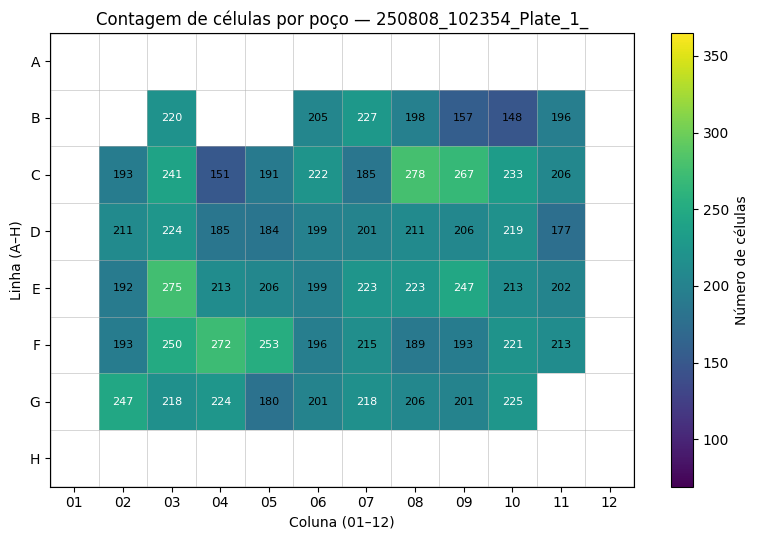

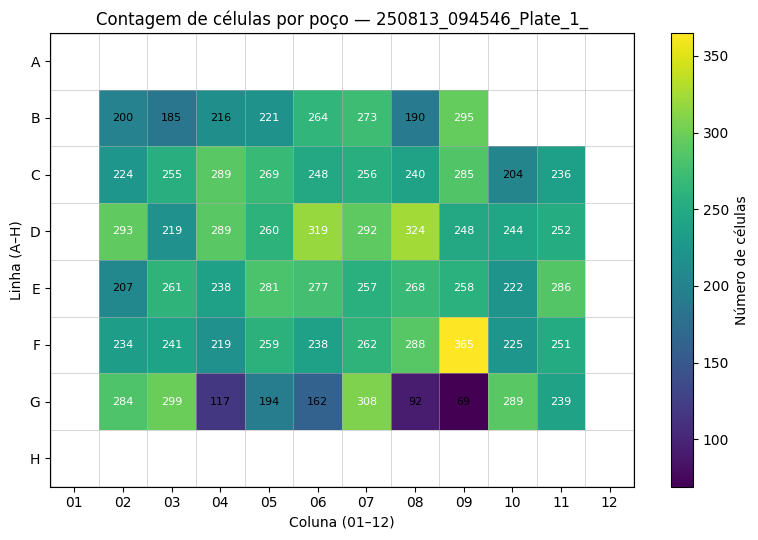

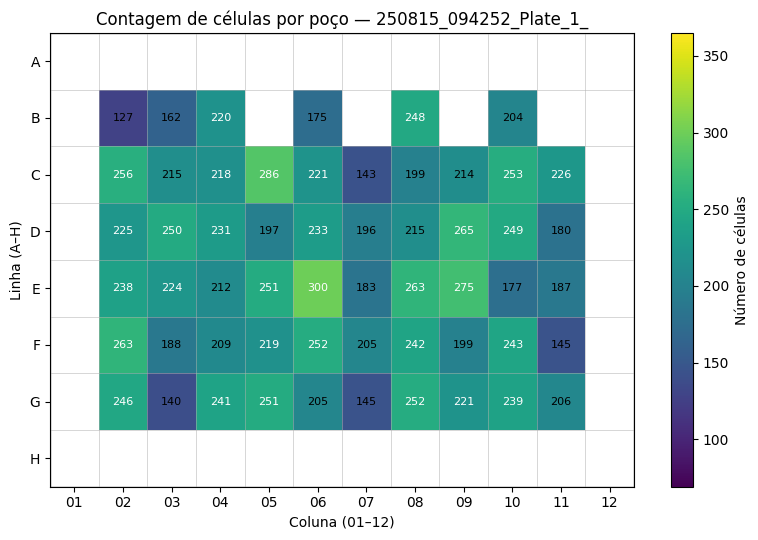

In [102]:
oc = (
    object_count
    .copy()
    .dropna(subset=["Metadata_Plate"])
    .query("Metadata_Plate != ''")
)
plot_all_plate_heatmaps(oc, match_scale=True)

## 7) Amostra do resultado

In [104]:
df_all.head()

,ImageNumber,Metadata_Plate,Metadata_Well,Metadata_Site,Cells_Number_Object_Number,Cells_AreaShape_Area,Cells_AreaShape_BoundingBoxArea,Cells_AreaShape_BoundingBoxMaximum_X,Cells_AreaShape_BoundingBoxMaximum_Y,Cells_AreaShape_BoundingBoxMinimum_X,Cells_AreaShape_BoundingBoxMinimum_Y,Cells_AreaShape_Center_X,Cells_AreaShape_Center_Y,Cells_AreaShape_CentralMoment_0_0,Cells_AreaShape_CentralMoment_0_1,Cells_AreaShape_CentralMoment_0_2,Cells_AreaShape_CentralMoment_0_3,Cells_AreaShape_CentralMoment_1_0,Cells_AreaShape_CentralMoment_1_1,Cells_AreaShape_CentralMoment_1_2,Cells_AreaShape_CentralMoment_1_3,Cells_AreaShape_CentralMoment_2_0,Cells_AreaShape_CentralMoment_2_1,Cells_AreaShape_CentralMoment_2_2,Cells_AreaShape_CentralMoment_2_3,Cells_AreaShape_Compactness,Cells_AreaShape_ConvexArea,Cells_AreaShape_Eccentricity,Cells_AreaShape_EquivalentDiameter,Cells_AreaShape_EulerNumber,Cells_AreaShape_Extent,Cells_AreaShape_FormFactor,Cells_AreaShape_HuMoment_0,Cells_AreaShape_HuMoment_1,Cells_AreaShape_HuMoment_2,Cells_AreaShape_HuMoment_3,Cells_AreaShape_HuMoment_4,Cells_AreaShape_HuMoment_5,Cells_AreaShape_HuMoment_6,Cells_AreaShape_InertiaTensorEigenvalues_0,Cells_AreaShape_InertiaTensorEigenvalues_1,Cells_AreaShape_InertiaTensor_0_0,Cells_AreaShape_InertiaTensor_0_1,Cells_AreaShape_InertiaTensor_1_0,Cells_AreaShape_InertiaTensor_1_1,Cells_AreaShape_MajorAxisLength,Cells_AreaShape_MaxFeretDiameter,Cells_AreaShape_MaximumRadius,Cells_AreaShape_MeanRadius,Cells_AreaShape_MedianRadius,Cells_AreaShape_MinFeretDiameter,Cells_AreaShape_MinorAxisLength,Cells_AreaShape_NormalizedMoment_0_0,Cells_AreaShape_NormalizedMoment_0_1,Cells_AreaShape_NormalizedMoment_0_2,Cells_AreaShape_NormalizedMoment_0_3,Cells_AreaShape_NormalizedMoment_1_0,Cells_AreaShape_NormalizedMoment_1_1,Cells_AreaShape_NormalizedMoment_1_2,Cells_AreaShape_NormalizedMoment_1_3,Cells_AreaShape_NormalizedMoment_2_0,Cells_AreaShape_NormalizedMoment_2_1,Cells_AreaShape_NormalizedMoment_2_2,Cells_AreaShape_NormalizedMoment_2_3,Cells_AreaShape_NormalizedMoment_3_0,Cells_AreaShape_NormalizedMoment_3_1,Cells_AreaShape_NormalizedMoment_3_2,Cells_AreaShape_NormalizedMoment_3_3,Cells_AreaShape_Orientation,Cells_AreaShape_Perimeter,Cells_AreaShape_Solidity,Cells_AreaShape_SpatialMoment_0_0,Cells_AreaShape_SpatialMoment_0_1,Cells_AreaShape_SpatialMoment_0_2,Cells_AreaShape_SpatialMoment_0_3,Cells_AreaShape_SpatialMoment_1_0,Cells_AreaShape_SpatialMoment_1_1,Cells_AreaShape_SpatialMoment_1_2,Cells_AreaShape_SpatialMoment_1_3,Cells_AreaShape_SpatialMoment_2_0,Cells_AreaShape_SpatialMoment_2_1,Cells_AreaShape_SpatialMoment_2_2,Cells_AreaShape_SpatialMoment_2_3,Cells_AreaShape_Zernike_0_0,Cells_AreaShape_Zernike_1_1,Cells_AreaShape_Zernike_2_0,Cells_AreaShape_Zernike_2_2,Cells_AreaShape_Zernike_3_1,Cells_AreaShape_Zernike_3_3,Cells_AreaShape_Zernike_4_0,Cells_AreaShape_Zernike_4_2,Cells_AreaShape_Zernike_4_4,Cells_AreaShape_Zernike_5_1,Cells_AreaShape_Zernike_5_3,Cells_AreaShape_Zernike_5_5,Cells_AreaShape_Zernike_6_0,Cells_AreaShape_Zernike_6_2,Cells_AreaShape_Zernike_6_4,Cells_AreaShape_Zernike_6_6,Cells_AreaShape_Zernike_7_1,...,Nuclei_Texture_InverseDifferenceMoment_AOPI_5_00_256,Nuclei_Texture_InverseDifferenceMoment_AOPI_5_01_256,Nuclei_Texture_InverseDifferenceMoment_AOPI_5_02_256,Nuclei_Texture_InverseDifferenceMoment_AOPI_5_03_256,Nuclei_Texture_SumAverage_AOGFP_10_00_256,Nuclei_Texture_SumAverage_AOGFP_10_01_256,Nuclei_Texture_SumAverage_AOGFP_10_02_256,Nuclei_Texture_SumAverage_AOGFP_10_03_256,Nuclei_Texture_SumAverage_AOGFP_20_00_256,Nuclei_Texture_SumAverage_AOGFP_20_01_256,Nuclei_Texture_SumAverage_AOGFP_20_02_256,Nuclei_Texture_SumAverage_AOGFP_20_03_256,Nuclei_Texture_SumAverage_AOGFP_5_00_256,Nuclei_Texture_SumAverage_AOGFP_5_01_256,Nuclei_Texture_SumAverage_AOGFP_5_02_256,Nuclei_Texture_SumAverage_AOGFP_5_03_256,Nuclei_Texture_SumAverage_AOPI_10_00_256,Nuclei_Texture_SumAverage_AOPI_10_01_256,Nuclei_Texture_SumAverage_AOPI_10_02_256,Nuclei_Texture_SumAverage_AOPI_10_03_256

---

## 🧯 Troubleshooting (ligado à prática aqui)

- **Chaves do merge não batem:** confira se `Metadata_ImageNumber` e `Metadata_ObjectNumber` existem em **todos** os compartimentos.  
- **Metadados essenciais ausentes:** `Metadata_Well` e `Metadata_Plate` são cruciais para agregação por poço.  
- **Colunas duplicadas:** revise a função de prefixo; metadados não devem receber prefixo.  
- **Queda de linhas após `merge`:** `inner` descarta objetos sem par correspondente; teste `outer` somente para diagnóstico.  
- **Arquivos gigantes:** prefira `.db` + `SELECT` com colunas necessárias; exporte para Parquet quando possível.

## ✅ Sanity checks úteis
- `df.columns.str.startswith("Metadata_")` → inspeção de metadados.  
- `df["Metadata_Well"].value_counts()` → contagem por poço.  
- `df.sample(5)` após cada etapa crítica para validar formato.  
- Salvar **contagens resumidas** (n por placa/poço) junto do `SingleCells`.

> Pronto! Agora este `SingleCells` está pronto para o **Pycytominer** e, em seguida, para análises como PCA/UMAP/clustering.